# MWE 50 - Body-fitted centered-vug FEM benchmark

This experiment reproduces the centered circular and spherical vug geometry
with Gmsh physical tags and solves the same mesh with Taylor-Hood and
`P1/DG1` USFEM. It checks flux parity between formulations and also exposes
the known `P1/DG0` high-contrast failure mode.

The benchmark is pressure-driven on the unit domain:

\[
\gamma_\mathrm{matrix}=10^7,\quad
\gamma_\mathrm{vug}=1,\quad
\nu=10^{-2},\quad p_L=1,\quad p_R=-1.
\]

In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import pandas as pd

try:
    from IPython.display import display
except ImportError:  # pragma: no cover - notebook convenience fallback
    display = print

from voids.examples.mms import (
    CenteredVugBenchmark,
    run_centered_vug_benchmark,
)
from voids.fem.singlephase import FEniCSSolverOptions

plt.ioff()

## Reproducible configuration

The report-scale values are approximately `resolution=96` in 2D and
`resolution=30` in 3D. The smaller defaults below are intended for a quick
end-to-end run and should not be presented as mesh-converged benchmark values.

In [2]:
benchmark_resolutions = {2: 8, 3: 6}
reference_methods = ("taylor_hood", "usfem_p1dg1")
run_low_order_2d_diagnostic = True
run_low_order_2d_safeguard_sensitivity = True
solver_options = FEniCSSolverOptions.superlu_direct()

## Run like-for-like body-fitted comparisons

In [3]:
rows = []
results_by_dimension = {}
for dimension, resolution in benchmark_resolutions.items():
    benchmark = CenteredVugBenchmark(
        dimension=dimension,
        resolution=resolution,
        mesh_representation="body_fitted",
    )
    methods = list(reference_methods)
    if dimension == 2 and run_low_order_2d_diagnostic:
        methods.append("usfem_p1dg0")
    dimension_results = {}
    for method in methods:
        print(f"Running {dimension}D {method} at nominal resolution {resolution}")
        result = run_centered_vug_benchmark(
            benchmark,
            method=method,
            options=solver_options,
        )
        dimension_results[method] = result
        rows.append(
            {
                "dimension": dimension,
                "resolution": resolution,
                "method": method,
                "cells": result.metadata["num_cells"],
                "facet_law": result.metadata["facet_law"],
                "facet_size_mode": result.metadata["facet_size_mode"],
                "analytic_vug_fraction": result.metadata["analytic_vug_fraction"],
                "represented_vug_fraction": result.metadata["represented_vug_fraction"],
                "flow_rate": result.flow_rate,
                "permeability_diagnostic": result.permeability,
                "solve_seconds": result.solve_seconds,
            }
        )
    results_by_dimension[dimension] = dimension_results

if run_low_order_2d_safeguard_sensitivity:
    benchmark = CenteredVugBenchmark(
        dimension=2,
        resolution=benchmark_resolutions[2],
        mesh_representation="body_fitted",
    )
    for label, controls in (
        ("usfem_p1dg0_tau0", {"tau_factor": 0.0}),
        ("usfem_p1dg0_cap0.5", {"tau_gamma_cap": 0.5}),
    ):
        print(f"Running 2D {label}")
        result = run_centered_vug_benchmark(
            benchmark,
            method="usfem_p1dg0",
            options=solver_options,
            **controls,
        )
        rows.append(
            {
                "dimension": 2,
                "resolution": benchmark.resolution,
                "method": label,
                "cells": result.metadata["num_cells"],
                "facet_law": result.metadata["facet_law"],
                "facet_size_mode": result.metadata["facet_size_mode"],
                "analytic_vug_fraction": result.metadata["analytic_vug_fraction"],
                "represented_vug_fraction": result.metadata["represented_vug_fraction"],
                "flow_rate": result.flow_rate,
                "permeability_diagnostic": result.permeability,
                "solve_seconds": result.solve_seconds,
            }
        )

summary = pd.DataFrame(rows)
reference_flux = summary.loc[
    summary["method"] == "taylor_hood", ["dimension", "flow_rate"]
].rename(columns={"flow_rate": "taylor_hood_flow_rate"})
summary = summary.merge(reference_flux, on="dimension")
summary["flux_ratio_to_taylor_hood"] = (
    summary["flow_rate"] / summary["taylor_hood_flow_rate"]
)
display(summary)

Running 2D taylor_hood at nominal resolution 8


Info    : Clearing all models and views...
Info    : Done clearing all models and views
Running 2D usfem_p1dg1 at nominal resolution 8
Info    : Clearing all models and views...
Info    : Done clearing all models and views


Running 2D usfem_p1dg0 at nominal resolution 8
Info    : Clearing all models and views...
Info    : Done clearing all models and views
Running 3D taylor_hood at nominal resolution 6
Info    : Clearing all models and views...
Info    : Done clearing all models and views


/var/folders/pv/5f4l3ck95cqf1c0h6y22r1wr0000gn/T/ipykernel_22304/4219064236.py:15: RuntimeWarning: The body-fitted CG1 x DG0 vug case has estimated max(gamma * tau_K)=1; the cell term can nearly cancel matrix drag. Set tau_gamma_cap below 1 or use tau_factor=0 as an explicit sensitivity branch.
  result = run_centered_vug_benchmark(


Running 3D usfem_p1dg1 at nominal resolution 6
Info    : Clearing all models and views...
Info    : Done clearing all models and views
Running 2D usfem_p1dg0_tau0


Info    : Clearing all models and views...
Info    : Done clearing all models and views
Running 2D usfem_p1dg0_cap0.5
Info    : Clearing all models and views...
Info    : Done clearing all models and views


,dimension,resolution,method,cells,facet_law,facet_size_mode,analytic_vug_fraction,represented_vug_fraction,flow_rate,permeability_diagnostic,solve_seconds,taylor_hood_flow_rate,flux_ratio_to_taylor_hood
0,2,8,taylor_hood,92,NaN,NaN,0.19635,0.180784,2.928291e-07,1.464146e-09,0.002661,2.928291e-07,1.000000e+00
1,2,8,usfem_p1dg1,92,reaction_diffusion,facet_measure,0.19635,0.180784,2.929807e-07,1.464904e-09,0.002712,2.928291e-07,1.000518e+00
2,2,8,usfem_p1dg0,92,reaction_diffusion,facet_measure,0.19635,0.180784,6.237671e-01,3.118835e-03,0.001419,2.928291e-07,2.130140e+06
3,3,6,taylor_hood,444,NaN,NaN,0.06545,0.039665,2.494432e-07,1.247216e-09,0.134161,2.494432e-07,1.000000e+00
4,3,6,usfem_p1dg1,444,shifted,facet_measure,0.06545,0.039665,2.134228e-07,1.067114e-09,0.141601,2.494432e-07,8.555970e-01
5,2,8,usfem_p1dg0_tau0,92,reaction_diffusion,facet_measure,0.19635,0.180784,4.034490e-07,2.017245e-09,0.001377,2.928291e-07,1.377763e+00
6,2,8,usfem_p1dg0_cap0.5,92,reaction_diffusion,facet_measure,0.19635,0.180784,6.894061e-07,3.447030e-09,0.001508,2.928291e-07,2.354294e+00


## Formulation parity checks

The 2D quick mesh should already give close `P1/DG1`/Taylor-Hood fluxes.
The 3D quick mesh is intentionally coarse, so its ratio is reported rather
than asserted as a mesh-converged value.

In [4]:
two_dimensional_ratio = summary.loc[
    (summary["dimension"] == 2) & (summary["method"] == "usfem_p1dg1"),
    "flux_ratio_to_taylor_hood",
].item()
assert abs(two_dimensional_ratio - 1.0) < 5.0e-3

parity = summary.loc[
    summary["method"].isin(reference_methods),
    [
        "dimension",
        "resolution",
        "method",
        "represented_vug_fraction",
        "flux_ratio_to_taylor_hood",
    ],
]
display(parity)

,dimension,resolution,method,represented_vug_fraction,flux_ratio_to_taylor_hood
0,2,8,taylor_hood,0.180784,1.000000
1,2,8,usfem_p1dg1,0.180784,1.000518
3,3,6,taylor_hood,0.039665,1.000000
4,3,6,usfem_p1dg1,0.039665,0.855597


## Flux comparison

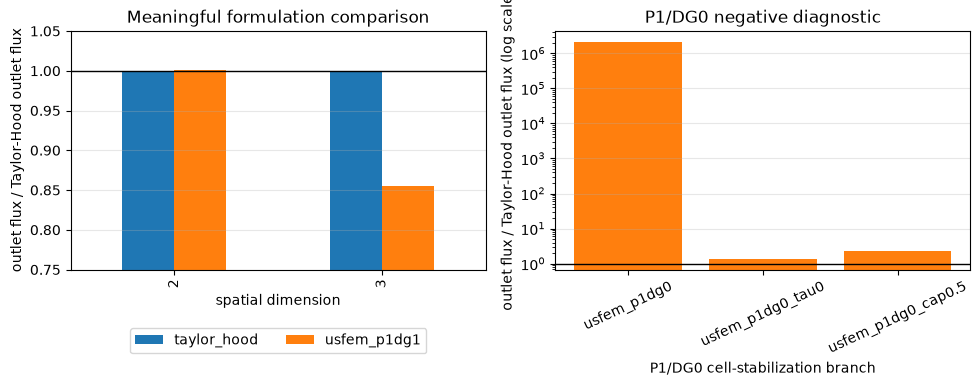

In [5]:
figure, axes = plt.subplots(1, 2, figsize=(10, 4))
reference_plot_table = summary.loc[summary["method"].isin(reference_methods)].pivot(
    index="dimension",
    columns="method",
    values="flux_ratio_to_taylor_hood",
)
reference_plot_table.plot.bar(ax=axes[0])
axes[0].legend(
    loc="lower center",
    bbox_to_anchor=(0.5, -0.38),
    ncol=2,
)
axes[0].axhline(1.0, color="black", linewidth=1.0)
axes[0].set_ylim(0.75, 1.05)
axes[0].set_ylabel("outlet flux / Taylor-Hood outlet flux")
axes[0].set_xlabel("spatial dimension")
axes[0].grid(True, axis="y", alpha=0.3)
axes[0].set_title("Meaningful formulation comparison")

low_order = summary.loc[
    summary["method"].str.startswith("usfem_p1dg0"),
    ["dimension", "method", "flux_ratio_to_taylor_hood"],
]
if low_order.empty:
    axes[1].set_visible(False)
else:
    axes[1].bar(
        low_order["method"],
        low_order["flux_ratio_to_taylor_hood"],
        color="tab:orange",
    )
    axes[1].set_yscale("log")
    axes[1].axhline(1.0, color="black", linewidth=1.0)
    axes[1].set_ylabel("outlet flux / Taylor-Hood outlet flux (log scale)")
    axes[1].set_xlabel("P1/DG0 cell-stabilization branch")
    axes[1].tick_params(axis="x", labelrotation=25)
    axes[1].grid(True, axis="y", alpha=0.3)
    axes[1].set_title("P1/DG0 negative diagnostic")
figure.tight_layout()
display(figure)
plt.close(figure)

## Interpretation and limitations

- Gmsh creates separate physical cell groups for the matrix and vug and
  physical facet groups for all outer faces and the internal interface.
- Both formulations in a dimension are regenerated deterministically from
  the same geometry and target size. Their flux comparison is therefore a
  like-for-like discretization check.
- The low-order `P1/DG0` row is a documented negative high-contrast result:
  its reaction-only volumetric term can nearly cancel matrix drag. A small
  divergence norm would not make that flux physically acceptable.
- The `tau0` and `cap0.5` rows are explicit sensitivity branches. The cap
  enforces \(\gamma\tau_K\le 0.5\), so at least half of the physical drag
  remains. Neither branch should be accepted without mesh refinement and a
  comparison to the Taylor-Hood reference.
- The reported permeability is a flow-based diagnostic for this boundary
  value problem. Quantitative comparison with report tables requires their
  finer nominal resolutions.